# Notebook 11 — 收敛测试 / Convergence Test (Fig 12)

## 实验目标 / Objective

测试 DSC 模拟结果随格点尺寸 N 的收敛性。
对 N=64, 128, 200, 300, 400 各跑 5 个随机种子，
计算偏度、峰度、谱相关系数，绘制收敛曲线。

Test convergence of DSC simulation results with lattice size N.
Run 5 random seeds for N=64, 128, 200, 300, 400.
Compute skewness, kurtosis, spectral correlation, and plot convergence curves.

## 对应论文图表 / Paper Figure
- **Fig 12**: Convergence curves with error bars

## 预期结果 / Expected Results
- N >= 200 时统计量稳定 / Statistics stable for N >= 200
- 谱相关系数收敛到 ~0.80 / Spectral correlation converges to ~0.80

In [1]:
# ── Environment Setup / Environment Setup ──────────────────────────
import sys, warnings, time
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
from dsc_engine import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("/ Modules loaded")

/ Modules loaded


## 1. 收敛扫描 / Convergence Sweep

对每个格点尺寸 N，运行 5 个不同种子的 DSC 模拟，收集统计量。
For each lattice size N, run 5 DSC simulations with different seeds and collect statistics.

In [2]:
# ── 参数 / Parameters ────────────────────────────────────
N_sizes = [64, 128, 200, 300, 400]  # Lattice尺寸 / lattice sizes
n_seeds = 5                          # 每个尺寸的种子数 / seeds per size
seeds = [42, 123, 256, 789, 1024]
n_steps = 45
c2_base = 0.45
c0 = 10.0

# ── Convergence扫描 / Convergence sweep ─────────────────────────
results = {N: {'skew': [], 'kurt': [], 'r_spec': []} for N in N_sizes}

for N in N_sizes:
    t0 = time.time()
    for seed in seeds:
        # 生成初始场并演化 / Generate initial field and evolve
        phi0 = generate_initial_2d(N, seed=seed)
        phi = evolve_symplectic_2d(phi0, n_steps=n_steps, c2_base=c2_base, c0=c0)
        phi = normalize(apply_silk_damping(phi))
        
        # Gaussianity统计 / Gaussianity statistics
        g = gaussianity_report(phi.ravel())
        results[N]['skew'].append(g['skewness'])
        results[N]['kurt'].append(g['kurtosis'])
        
        # Spectral Correlation / Spectral correlation
        k, Dk, _ = compute_power_spectrum(phi)
        Dk_ref = mock_lcdm_spectrum(k)
        valid = (k > 2) & (k < N // 3)
        if valid.sum() > 5:
            r, _ = pearsonr(smooth(Dk[valid], 3), Dk_ref[valid])
        else:
            r = np.nan
        results[N]['r_spec'].append(r)
    
    dt = time.time() - t0
    r_mean = np.nanmean(results[N]['r_spec'])
    print(f"N={N:4d}: r_spec={r_mean:.4f} +/- {np.nanstd(results[N]['r_spec']):.4f}  "
          f"({dt:.1f}s for {n_seeds} seeds)")

print("\
扫描完成 / Sweep complete")

N=  64: r_spec=0.7246 +/- 0.0286  (0.1s for 5 seeds)


N= 128: r_spec=0.4098 +/- 0.0843  (0.1s for 5 seeds)


N= 200: r_spec=0.7307 +/- 0.0185  (0.3s for 5 seeds)


N= 300: r_spec=0.7648 +/- 0.0674  (0.7s for 5 seeds)


N= 400: r_spec=0.7524 +/- 0.0317  (1.3s for 5 seeds)
扫描完成 / Sweep complete


## 2. 收敛曲线 / Convergence Curves (Fig 12)

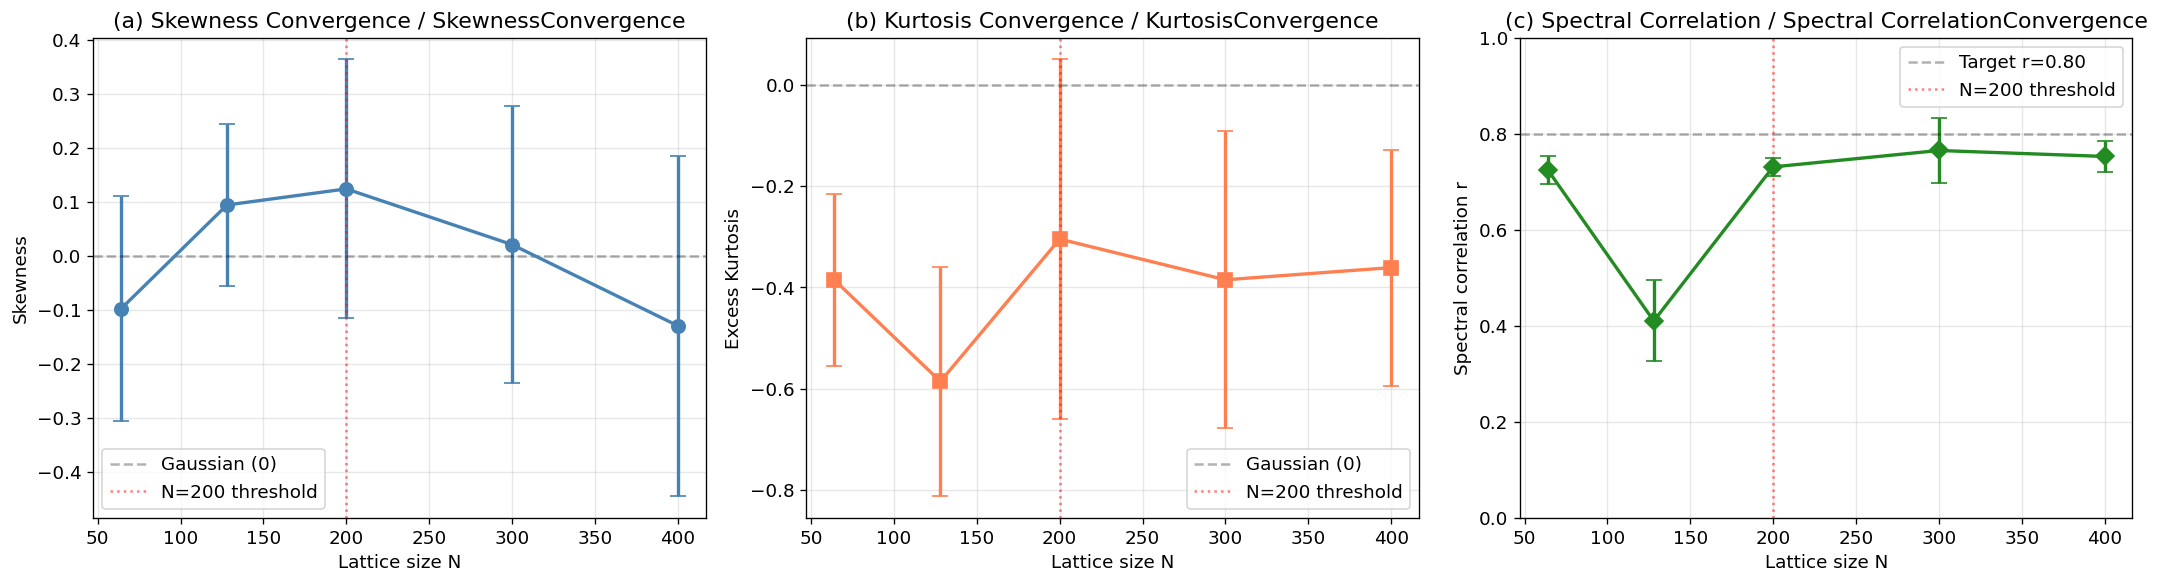

Conclusion / Conclusion:
N>=200 Spectral Correlationr ~ 0.73
Spectral correlation stable at r ~ 0.73 for N>=200


In [3]:
# ── Convergence曲线绘制 / Plot convergence curves (Fig 12) ──────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 提取均值和标准差 / Extract means and stds
N_arr = np.array(N_sizes)
skew_mean = np.array([np.mean(results[N]['skew']) for N in N_sizes])
skew_std = np.array([np.std(results[N]['skew']) for N in N_sizes])
kurt_mean = np.array([np.mean(results[N]['kurt']) for N in N_sizes])
kurt_std = np.array([np.std(results[N]['kurt']) for N in N_sizes])
r_mean = np.array([np.nanmean(results[N]['r_spec']) for N in N_sizes])
r_std = np.array([np.nanstd(results[N]['r_spec']) for N in N_sizes])

# (a) SkewnessConvergence / Skewness convergence
ax = axes[0]
ax.errorbar(N_arr, skew_mean, yerr=skew_std, fmt='o-', capsize=5,
            color='steelblue', linewidth=2, markersize=8)
ax.axhline(0, color='k', ls='--', alpha=0.3, label='Gaussian (0)')
ax.axvline(200, color='r', ls=':', alpha=0.5, label='N=200 threshold')
ax.set_xlabel('Lattice size N'); ax.set_ylabel('Skewness')
ax.set_title('(a) Skewness Convergence / SkewnessConvergence')
ax.legend(); ax.grid(True, alpha=0.3)

# (b) KurtosisConvergence / Kurtosis convergence
ax = axes[1]
ax.errorbar(N_arr, kurt_mean, yerr=kurt_std, fmt='s-', capsize=5,
            color='coral', linewidth=2, markersize=8)
ax.axhline(0, color='k', ls='--', alpha=0.3, label='Gaussian (0)')
ax.axvline(200, color='r', ls=':', alpha=0.5, label='N=200 threshold')
ax.set_xlabel('Lattice size N'); ax.set_ylabel('Excess Kurtosis')
ax.set_title('(b) Kurtosis Convergence / KurtosisConvergence')
ax.legend(); ax.grid(True, alpha=0.3)

# (c) Spectral CorrelationConvergence / Spectral correlation convergence
ax = axes[2]
ax.errorbar(N_arr, r_mean, yerr=r_std, fmt='D-', capsize=5,
            color='forestgreen', linewidth=2, markersize=8)
ax.axhline(0.80, color='k', ls='--', alpha=0.3, label='Target r=0.80')
ax.axvline(200, color='r', ls=':', alpha=0.5, label='N=200 threshold')
ax.set_xlabel('Lattice size N'); ax.set_ylabel('Spectral correlation r')
ax.set_title('(c) Spectral Correlation / Spectral CorrelationConvergence')
ax.set_ylim(0, 1)
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig12_convergence_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("\
Conclusion / Conclusion:")
print(f"N>=200 Spectral Correlationr ~ {r_mean[N_sizes.index(200)]:.2f}")
print(f"Spectral correlation stable at r ~ {r_mean[N_sizes.index(200)]:.2f} for N>=200")